# London Gift Shop – Retail Data Analytics

This notebook analyzes historical transaction data from the London Gift Shop (LGS) to understand customer purchasing behavior and sales patterns.

The goal of this analysis is to generate actionable insights that can help the marketing team design targeted campaigns and promotions.


## Data Source & Loading Strategy

The transactional data was provided by the LGS IT team as a PostgreSQL dump after removing all personally identifiable information (PII).

For analytics:
- Data is loaded from PostgreSQL into a Pandas DataFrame
- Each row represents a transaction line item
- Invoice-level metrics are derived by aggregation


# Load Data from PSQL into DataFrame

**Setup Docker Containers**

![](https://i.imgur.com/VQrBVBk.jpg)



In [0]:


#Read data from CSV from volume inside databricks
#df = pd.read_csv("london_giftshop_data.csv")

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


* The dataset represents item-level retail transactions with pricing, customer, and location details.

* Multiple products per invoice indicate basket purchasing behavior.

* Customer and date fields enable customer-level and time-based sales analysis.

## Load CSV into Dataframe
Alternatively, the LGS IT team also dumped the transactional data into a CSV file. However, the CSV header (column names) doesn't follow the snakecase or camelcase naming convention (e.g. Customer ID instead of customer_id or CustomerID). As a result, we  will need to use Pandas to clean up the data before doing any analytics. In addition, unlike the PSQL scheme, CSV files do not have data types associated. Therefore,  we need to cast/convert certain columns into correct data types (e.g. DateTime, numbers, etc..)

In [0]:
import pandas as pd

# Step 1: URL
url = "https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv"

# Step 2: Load data
retail_df = pd.read_csv(url)

# Step 3: Save to volume
file_path = "/Volumes/london_giftshop_retail_analytics/default/data/online_retail_II.csv"

df.to_csv(file_path, index=False)

print("File saved successfully!")
df = retail_df

# --- Rename columns to snake_case ---
retail_df.rename(columns={
    'Invoice': 'invoice',
    'StockCode': 'stock_code',
    'Description': 'description',
    'Quantity': 'quantity',
    'InvoiceDate': 'invoice_date',
    'Price': 'price',
    'Customer ID': 'customer_id',
    'Country': 'country'
}, inplace=True)

# --- Convert types ---
retail_df['invoice_date'] = pd.to_datetime(retail_df['invoice_date'])

# Create a total amount column (Quantity * Price) to help with later calculations
retail_df['amount'] = retail_df['quantity'] * retail_df['price']

# Remove rows with missing Customer IDs for better analytics (optional but recommended)
# retail_df.dropna(subset=['customer_id'], inplace=True)
# retail_df['customer_id'] = retail_df['customer_id'].astype(int)

retail_df.head()

File saved successfully!


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [0]:
#Display data types
df.dtypes  

invoice                 object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
price                  float64
customer_id            float64
country                 object
amount                 float64
dtype: object

# Descriptive Statistics & Null Checks

In [0]:
#Display dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice       1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   price         1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  object        
 8   amount        1067371 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 73.3+ MB


In [0]:
#Check for missing values
df.isna().any()


invoice         False
stock_code      False
description      True
quantity        False
invoice_date    False
price           False
customer_id      True
country         False
amount          False
dtype: bool

In [0]:
#Display statistical summary
df.describe()

,quantity,invoice_date,price,customer_id,amount
count,1.067371e+06,1067371,1.067371e+06,824364.000000,1.067371e+06
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504,1.806987e+01
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,-1.684696e+05
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,3.750000e+00
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,9.900000e+00
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,1.770000e+01
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,1.684696e+05
std,1.727058e+02,NaN,1.235531e+02,1697.464450,2.924202e+02


The dataset is largely complete and reliable, with minimal missing values.

Data quality is sufficient to support downstream customer and revenue analysis.

Any gaps can be handled without materially impacting business conclusions.

## Feature Engineering – Line Total

To support invoice-level analysis, a new feature `line_total` is created.

`line_total = quantity × price`

This represents the monetary contribution of each transaction line.


In [0]:
# Step 1.1 — create line total for each row
df["line_total"] = df["quantity"] * df["price"]

# Step 1.2 — calculate total invoice amount
invoice_amount_df = (
    df.groupby("invoice")["line_total"]
      .sum()
      .reset_index(name="invoice_amount")
)

invoice_amount_df.head()

,invoice,invoice_amount
0,489434,505.30
1,489435,145.80
2,489436,630.33
3,489437,310.75
4,489438,2286.24


In [0]:
# Display statistical summary of invoice amounts
invoice_amount_df.describe()



,invoice_amount
count,53628.000000
mean,359.648888
std,1654.829288
min,-168469.600000
25%,0.000000
50%,196.345000
75%,403.652500
max,168469.600000


## Invoice Amount Distribution

We analyze the distribution of invoice amounts to understand:
- Typical invoice size
- Spending variability
- Presence of unusually large invoices

Visualizations such as histograms and boxplots are used to study the spread and skewness of the data.


In [0]:
# Install and import visualization libraries
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


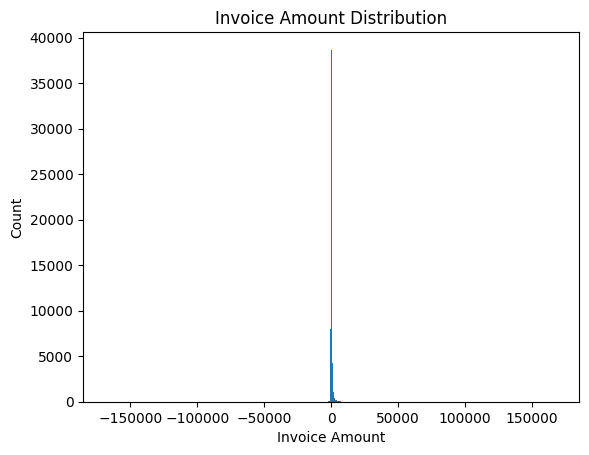

In [0]:
# Plot histogram of invoice amounts
plt.figure()
plt.hist(invoice_amount_df["invoice_amount"], bins=500)
plt.xlabel("Invoice Amount")
plt.ylabel("Count")
plt.title("Invoice Amount Distribution")
plt.show()


Most invoices are low to mid-value, with a small number of high-value purchases.

Revenue is not evenly distributed across transactions.

A minority of invoices contribute disproportionately to total sales.


# Understanding Skewness & Outliers

The invoice distribution is highly right-skewed:
- Most invoices are small to medium in value
- A small number of bulk purchases significantly increase the mean

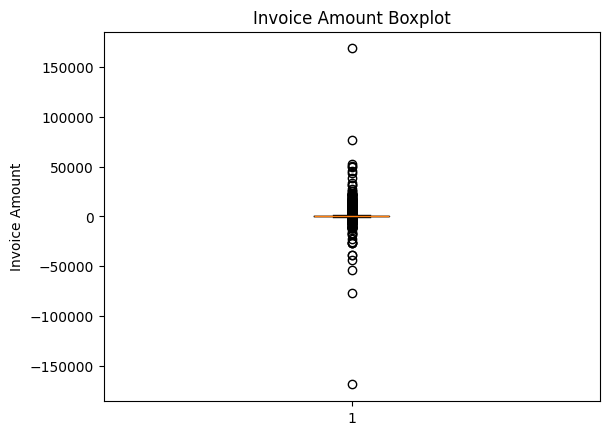

In [0]:
# Plot boxplot of invoice amounts
plt.figure()
plt.boxplot(invoice_amount_df["invoice_amount"], vert=True)
plt.ylabel("Invoice Amount")
plt.title("Invoice Amount Boxplot")
plt.show()


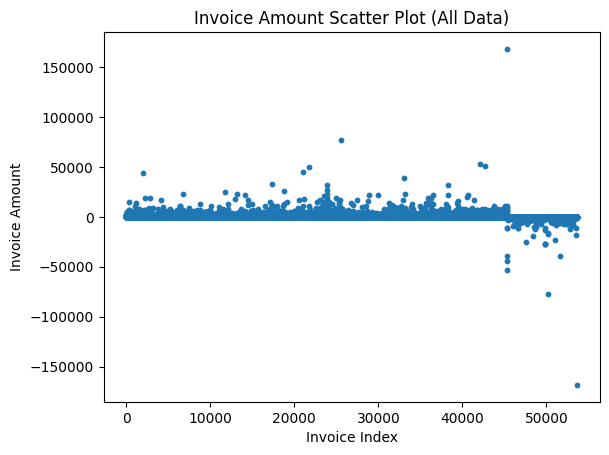

In [0]:
# Plot scatter plot of invoice amounts
plt.figure()
plt.scatter(range(len(invoice_amount_df["invoice_amount"])), invoice_amount_df["invoice_amount"], s=10)
plt.xlabel("Invoice Index")
plt.ylabel("Invoice Amount")
plt.title("Invoice Amount Scatter Plot (All Data)")
plt.show()


# Quantile-Based Analysis

Quantile analysis highlights how revenue concentration increases at higher spend levels.

Top-spending invoices drive a large share of overall revenue.

This supports targeted strategies rather than uniform customer treatment.

In [0]:
# Calculate and display quantiles of invoice amounts
quantile_levels = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.85, 0.90, 0.95, 0.99, 1.00]

quantiles = invoice_amount_df["invoice_amount"].quantile(quantile_levels)

quantiles_df = quantiles.reset_index()
quantiles_df.columns = ["Quantile", "Invoice_Amount"]
quantiles_df


,Quantile,Invoice_Amount
0,0.01,-302.4000
1,0.05,-31.3395
2,0.10,-11.8000
3,0.25,0.0000
4,0.50,196.3450
5,0.75,403.6525
6,0.85,594.0095
7,0.90,776.7400
8,0.95,1252.9825
9,0.99,3840.1780


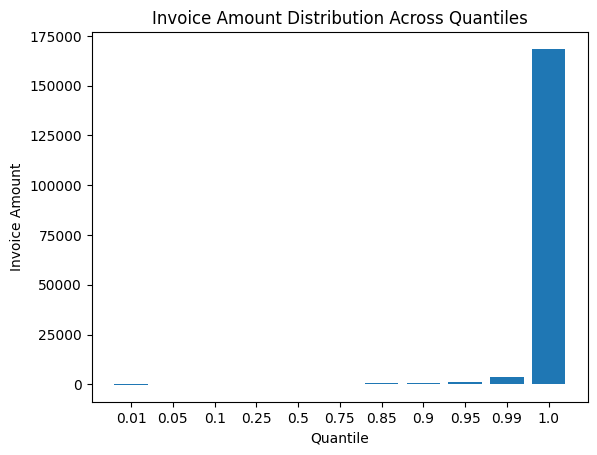

In [0]:
# Plot bar chart of invoice amount quantiles
plt.figure()
plt.bar(quantiles_df["Quantile"].astype(str), quantiles_df["Invoice_Amount"])
plt.xlabel("Quantile")
plt.ylabel("Invoice Amount")
plt.title("Invoice Amount Distribution Across Quantiles")
plt.show()


The sharp rise in the upper quantiles confirms that a small fraction of invoices accounts for a disproportionate amount of revenue.

# Focused Analysis up to 85th Percentile

Removing extreme outliers reveals the behavior of the core customer base.

Most customers exhibit consistent, moderate spending patterns.

This segment represents stable, predictable revenue.

In [0]:

# Import pivot_table function
from pandas.core.reshape.pivot import pivot_table

In [0]:
# Calculate the 85th percentile of invoice amounts
q85 = invoice_amount_df["invoice_amount"].quantile(0.85)
q85


np.float64(594.0095)

In [0]:
# Filter invoices below or equal to the 85th percentile
invoice_85 = invoice_amount_df[
    invoice_amount_df["invoice_amount"] <= q85
]


In [0]:
# Display statistical summary of filtered invoices
invoice_85.describe()


,invoice_amount
count,45583.000000
mean,136.977568
std,1071.983325
min,-168469.600000
25%,0.000000
50%,141.900000
75%,308.330000
max,594.000000


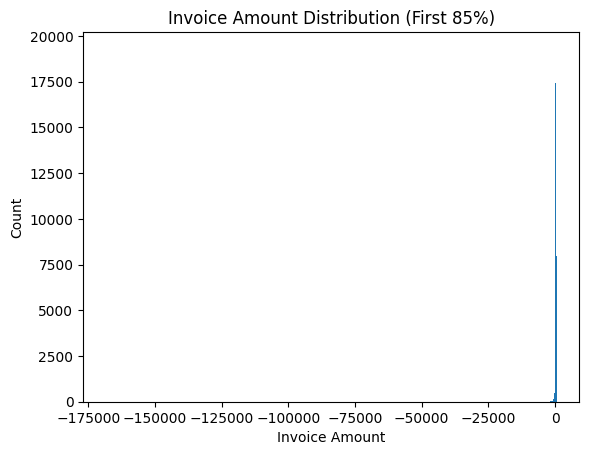

In [0]:
# Plot histogram of filtered invoice amounts
plt.figure()
plt.hist(invoice_85["invoice_amount"], bins=700)
plt.xlabel("Invoice Amount")
plt.ylabel("Count")
plt.title("Invoice Amount Distribution (First 85%)")
plt.show()


In [0]:
# Calculate the quantiles for the filtered invoices
quantiles = invoice_amount_df["invoice_amount"].quantile([0.1, 0.25, 0.5, 0.75, 0.85])

quantiles_df = quantiles.reset_index()
quantiles_df.columns = ["Quantile", "Invoice_Amount"]
quantiles_df


,Quantile,Invoice_Amount
0,0.10,-11.8000
1,0.25,0.0000
2,0.50,196.3450
3,0.75,403.6525
4,0.85,594.0095


Bar graph for 85% range

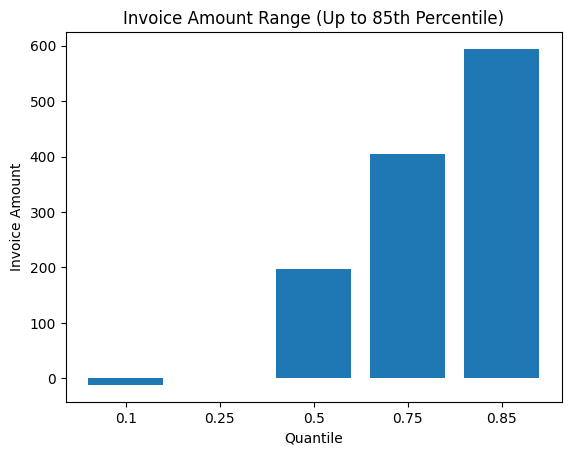

In [0]:
# Plot bar chart of filtered invoice amount quantiles
plt.figure()
plt.bar(quantiles_df["Quantile"].astype(str), quantiles_df['Invoice_Amount'])
plt.xlabel("Quantile")
plt.ylabel("Invoice Amount")
plt.title("Invoice Amount Range (Up to 85th Percentile)")
plt.show()


# Monthly Sales Analysis

Sales show clear monthly variation, indicating seasonality.

Certain months consistently outperform others.

Inventory and marketing planning should align with these patterns.

In [0]:
# Ensure datetime + YearMonth columns for time series analysis
df["invoice_date"] = pd.to_datetime(df["invoice_date"])

df["YearMonth"] = df["invoice_date"].dt.to_period("M").astype(str)

In [0]:
#Compute monthly sales
df["line_total"] = df["quantity"] * df["price"]

monthly_sales = (
    df.groupby("YearMonth")["line_total"]
      .sum()
      .reset_index(name="Sales")
      .sort_values("YearMonth")
)

monthly_sales


,YearMonth,Sales
0,2009-12,799847.110
1,2010-01,624032.892
2,2010-02,533091.426
3,2010-03,765848.761
4,2010-04,590580.432
5,2010-05,615322.830
6,2010-06,679786.610
7,2010-07,575236.360
8,2010-08,656776.340
9,2010-09,853650.431


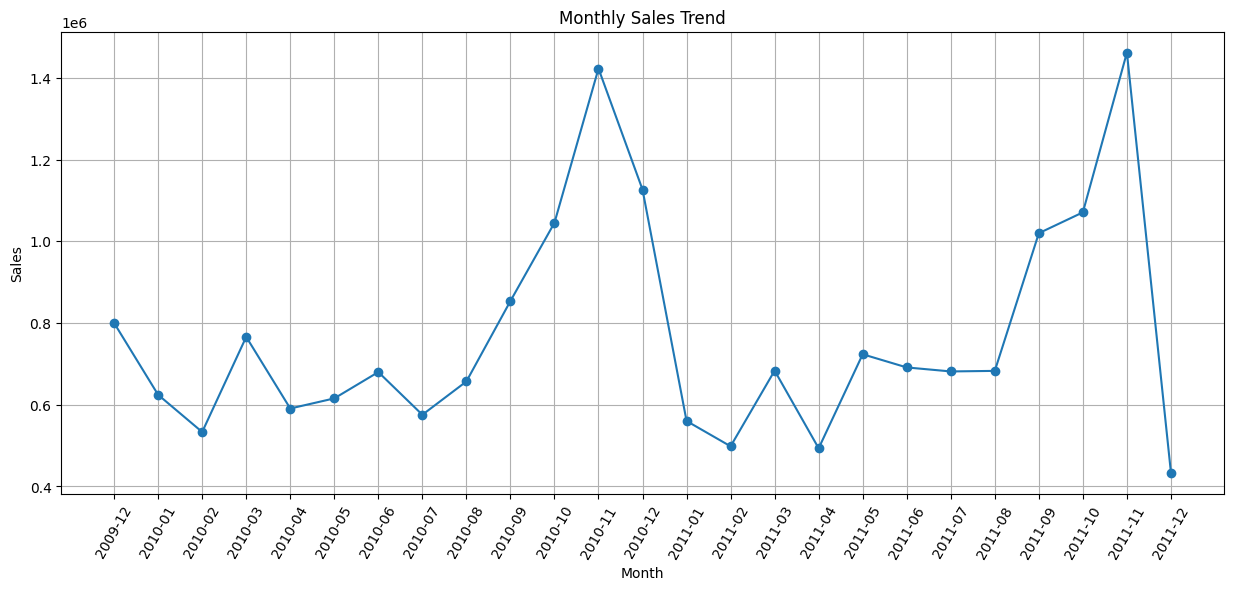

In [0]:
#plot monthly sales
plt.figure(figsize=(15,6))
plt.plot(monthly_sales["YearMonth"], monthly_sales["Sales"], marker="o")
plt.xticks(rotation=60)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.grid(True)
plt.show()
  

*Findings*


Holiday season = highest sales period - November

Both 2010 and 2011 follow the same rhythm:

Spring = moderate

Summer = stable

Autumn = growth

November = peak

The monthly sales trend reveals strong seasonality. Revenue consistently peaks in November during the holiday season and drops sharply afterward, repeating the same pattern across years

In [0]:
# select top 10 invoices by aggregated invoice amount
top_10 = invoice_amount_df.nlargest(n=10, columns='invoice_amount')
#top_10.to_csv('top_100_invoices.csv')
top_10

,invoice,invoice_amount
45294,581483,168469.60
25572,541431,77183.60
42045,574941,52940.94
42737,576365,50653.91
21730,533027,49844.99
21034,531516,45332.97
2063,493819,44051.60
33010,556444,38970.00
17340,524181,33167.80
23943,537659,31770.98


# Monthly Sales Growth
Growth trends fluctuate rather than increasing steadily.

Periods of expansion are followed by slowdowns or declines.

Highlights the need for proactive demand-stimulation strategies.

In [0]:
#Calculate monthly growth %
monthly_sales["Growth_%"] = monthly_sales["Sales"].pct_change() * 100
monthly_sales


,YearMonth,Sales,Growth_%
0,2009-12,799847.110,NaN
1,2010-01,624032.892,-21.980978
2,2010-02,533091.426,-14.573185
3,2010-03,765848.761,43.661804
4,2010-04,590580.432,-22.885501
5,2010-05,615322.830,4.189505
6,2010-06,679786.610,10.476416
7,2010-07,575236.360,-15.379863
8,2010-08,656776.340,14.175039
9,2010-09,853650.431,29.975820


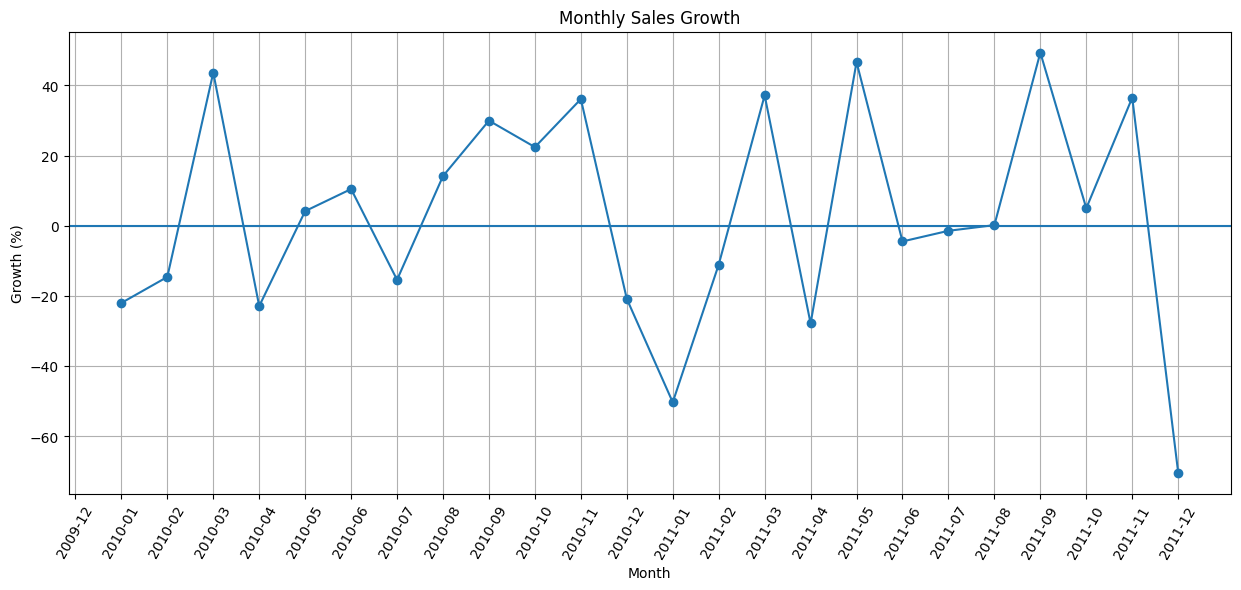

In [0]:
#Plot growth %
plt.figure(figsize=(15,6))
plt.plot(monthly_sales["YearMonth"], monthly_sales["Growth_%"], marker="o")
plt.axhline(0)  # zero growth reference
plt.xticks(rotation=60)
plt.xlabel("Month")
plt.ylabel("Growth (%)")
plt.title("Monthly Sales Growth")
plt.grid(True)
plt.show()


# Monthly Placed vs Canceled Orders

Invoices starting with "C" are treated as canceled.

Order cancellations form a noticeable portion of total activity.

Monitoring cancellation trends is important to protect revenue.

Potential operational or customer satisfaction issues may exist.

In [0]:
#Create YearMonth
df["invoice_date"] = pd.to_datetime(df["invoice_date"])
df["YearMonth"] = df["invoice_date"].dt.to_period("M").astype(str)


In [0]:
#Identify canceled invoices
df["is_canceled"] = df["invoice"].astype(str).str.startswith("C")

In [0]:
#Count total invoices per month
total_orders = (
    df.groupby("YearMonth")["invoice"]
      .nunique()
      .reset_index(name="TotalOrders")
)
total_orders

,YearMonth,TotalOrders
0,2009-12,2330
1,2010-01,1633
2,2010-02,1969
3,2010-03,2367
4,2010-04,1892
5,2010-05,2418
6,2010-06,2216
7,2010-07,2017
8,2010-08,1877
9,2010-09,2375


In [0]:
#Count canceled invoices per month  
canceled_orders = (
    df[df["is_canceled"]]
      .groupby("YearMonth")["invoice"]
      .nunique()
      .reset_index(name="CanceledInvoices")
)
canceled_orders

,YearMonth,CanceledInvoices
0,2009-12,401
1,2010-01,300
2,2010-02,240
3,2010-03,407
4,2010-04,304
5,2010-05,407
6,2010-06,357
7,2010-07,344
8,2010-08,273
9,2010-09,371


In [0]:
#Merge and compute placed orders
monthly_orders = total_orders.merge(canceled_orders, on="YearMonth", how="left")
monthly_orders["CanceledInvoices"] = monthly_orders["CanceledInvoices"].fillna(0)

monthly_orders["PlacedOrders"] = (
    monthly_orders["TotalOrders"] - 2 * monthly_orders["CanceledInvoices"]
)

monthly_orders


,YearMonth,TotalOrders,CanceledInvoices,PlacedOrders
0,2009-12,2330,401,1528
1,2010-01,1633,300,1033
2,2010-02,1969,240,1489
3,2010-03,2367,407,1553
4,2010-04,1892,304,1284
5,2010-05,2418,407,1604
6,2010-06,2216,357,1502
7,2010-07,2017,344,1329
8,2010-08,1877,273,1331
9,2010-09,2375,371,1633


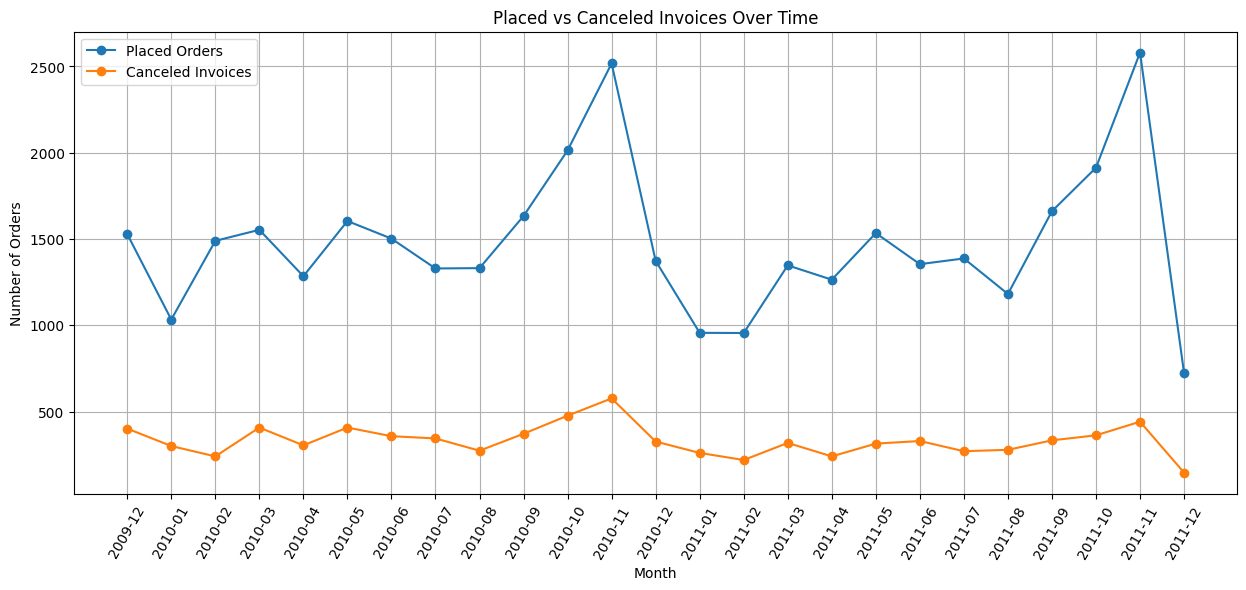

In [0]:
#placed vs cancelled percentage plot
plt.figure(figsize=(15,6))
plt.plot(monthly_orders["YearMonth"], monthly_orders["PlacedOrders"], marker="o", label="Placed Orders")
plt.plot(monthly_orders["YearMonth"], monthly_orders["CanceledInvoices"], marker="o", label="Canceled Invoices")
plt.xticks(rotation=60)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Placed vs Canceled Invoices Over Time")


plt.legend()
plt.grid(True)
plt.show()


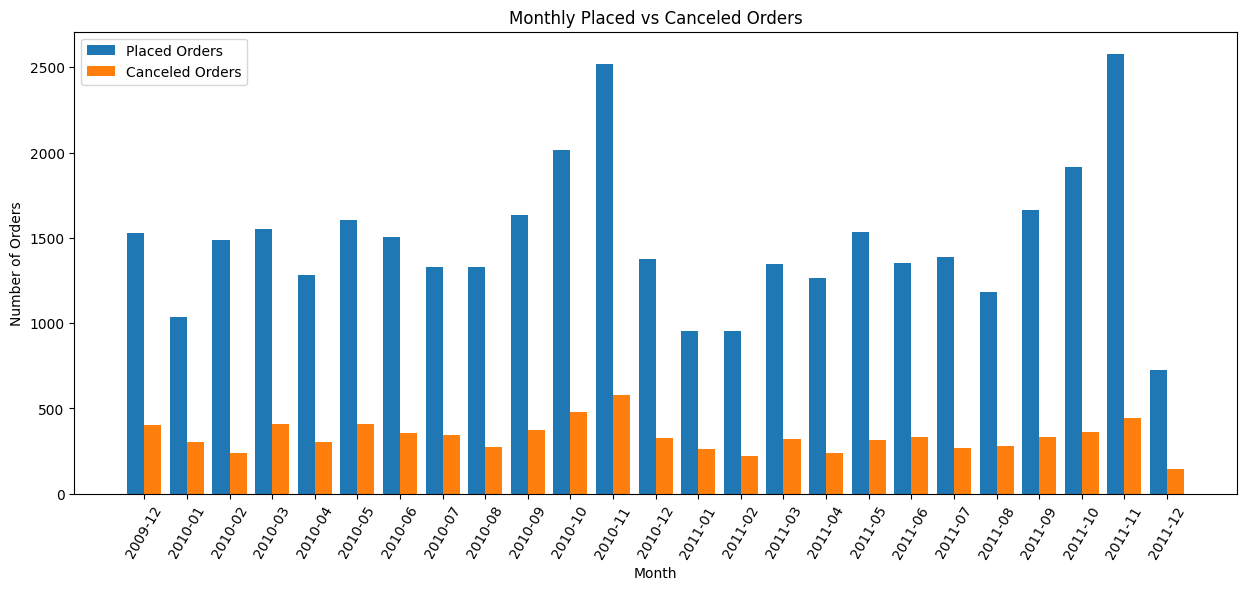

In [0]:
#Grouped bar graph - side by side 
import numpy as np

x = np.arange(len(monthly_orders["YearMonth"]))
width = 0.4

plt.figure(figsize=(15,6))

plt.bar(x - width/2, monthly_orders["PlacedOrders"], width, label="Placed Orders")
plt.bar(x + width/2, monthly_orders["CanceledInvoices"], width, label="Canceled Orders")

plt.xticks(x, monthly_orders["YearMonth"], rotation=60)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Placed vs Canceled Orders")
plt.legend()
plt.show()


This grouped bar chart makes it easy to compare placed and canceled orders per month

# Monthly Active Users (MAU)
Monthly active users measures how many unique customers placed at least one order per month. This shows customer engagement and growth over time.
Active customer counts vary month-to-month.

Revenue changes are partly driven by user engagement levels.

Retention directly impacts sales stability.

In [0]:
#Create YearMonth column
df["InvoiceYearMonth"] = df["invoice_date"].dt.to_period("M").astype(str)


In [0]:
monthly_active_users = (
    df.groupby("InvoiceYearMonth")["customer_id"]
      .nunique()
      .reset_index(name="ActiveUsers")
)


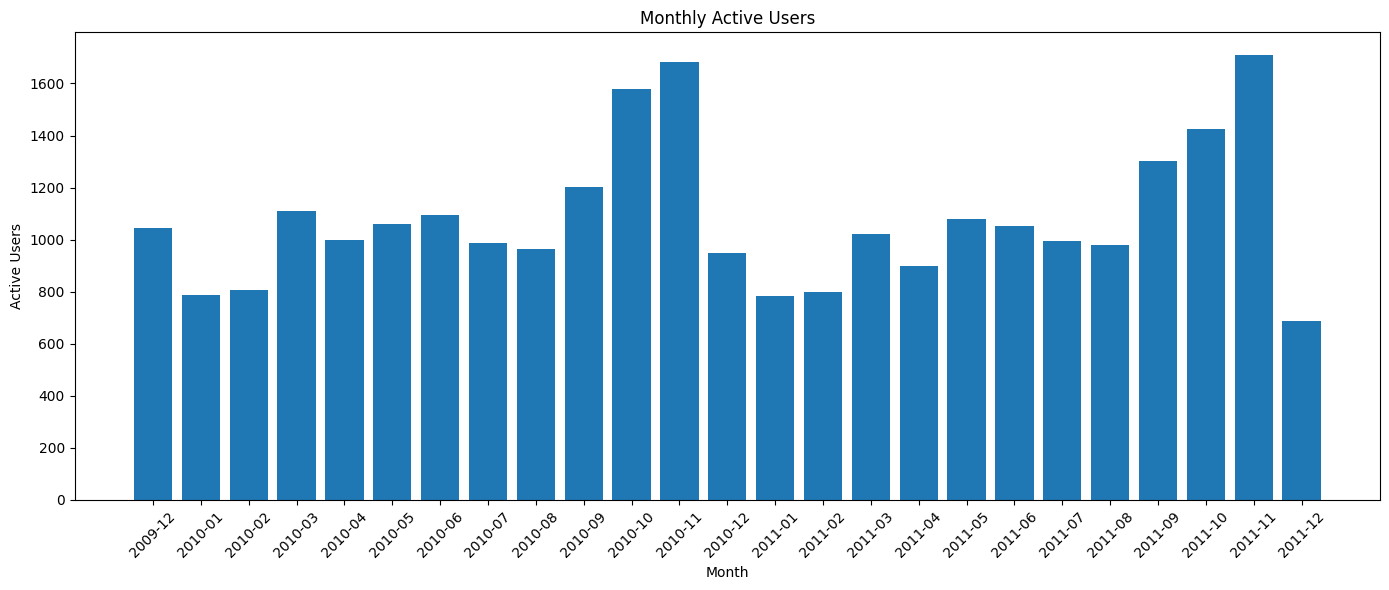

In [0]:
plt.figure(figsize=(14,6))
plt.bar(monthly_active_users["InvoiceYearMonth"], monthly_active_users["ActiveUsers"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Active Users")
plt.title("Monthly Active Users")
plt.tight_layout()
plt.show()


# New vs Existing Users

Existing customers contribute the majority of transactions.

New customer acquisition occurs but at a slower pace.

Retention is more critical than acquisition for sustained revenue.

In [0]:
#First purchase month for each customer
first_purchase = (
    df.groupby("customer_id")["InvoiceYearMonth"]
      .min()
      .reset_index(name="FirstMonth")
)


In [0]:
#Attach this back to main data
df_users = df.merge(first_purchase, on="customer_id", how="left")


In [0]:
#Classify each row: New or Existing
df_users["UserType"] = np.where(
    df_users["InvoiceYearMonth"] == df_users["FirstMonth"],
    "New",
    "Existing"
)


In [0]:
#Count users per month by type
user_counts = (
    df_users.groupby(["InvoiceYearMonth", "UserType"])["customer_id"]
            .nunique()
            .reset_index()
)


In [0]:
#Reshape for plotting
user_pivot = user_counts.pivot(
    index="InvoiceYearMonth",
    columns="UserType",
    values="customer_id"
).fillna(0)


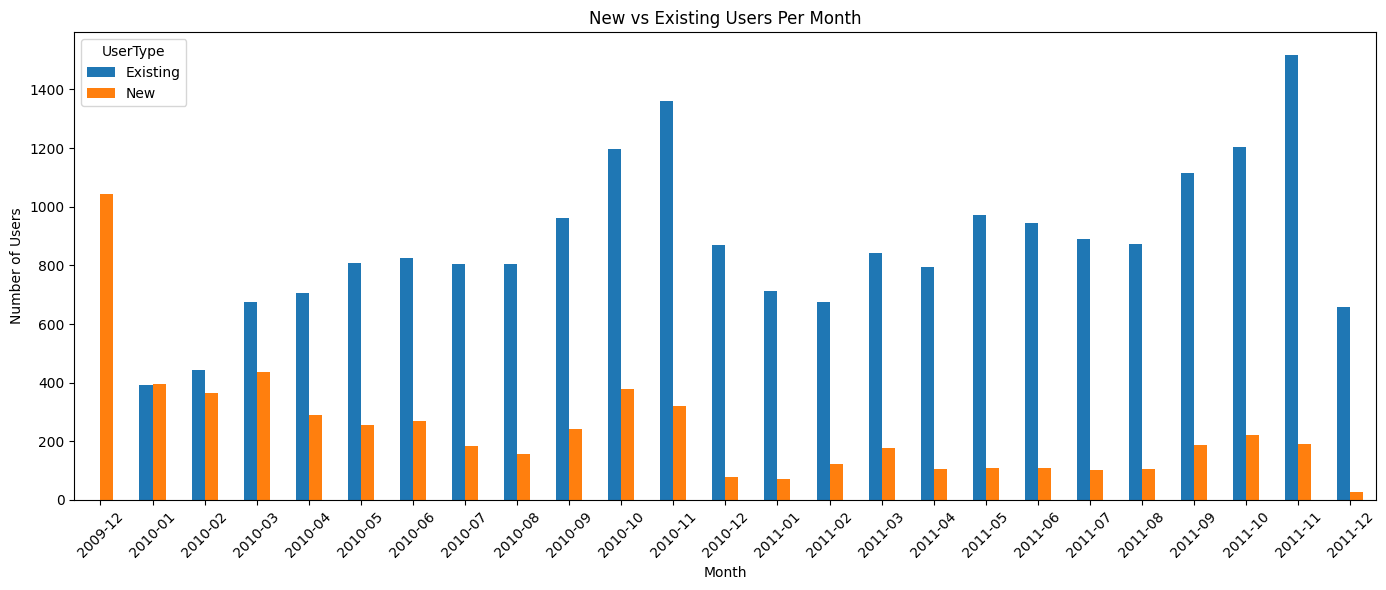

In [0]:
#Plot the result
user_pivot.plot(kind="bar", figsize=(14,6))
plt.xlabel("Month")
plt.ylabel("Number of Users")
plt.title("New vs Existing Users Per Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


We classified users based on their first purchase month.
If a customer’s transaction happens in their first month, they are new; otherwise existing.
The results show strong retention over time, with most sales coming from repeat customers and new customer acquisition peaking during seasonal periods.

# RFM Analysis – Customer Value Segmentation

Customers show clear differences in recency, frequency, and spending.

Not all customers contribute equally to business value.

Segmentation enables focused retention and upsell strategies.

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   invoice           1067371 non-null  object        
 1   stock_code        1067371 non-null  object        
 2   description       1062989 non-null  object        
 3   quantity          1067371 non-null  int64         
 4   invoice_date      1067371 non-null  datetime64[ns]
 5   price             1067371 non-null  float64       
 6   customer_id       824364 non-null   float64       
 7   country           1067371 non-null  object        
 8   amount            1067371 non-null  float64       
 9   line_total        1067371 non-null  float64       
 10  YearMonth         1067371 non-null  object        
 11  is_canceled       1067371 non-null  bool          
 12  InvoiceYearMonth  1067371 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(4),

In [0]:
# ensure invoice_no is string (safe)
df["invoice"] = df["invoice"].astype(str)

In [0]:
# RFM should be customer-based → remove missing customer_id rows
df_rfm = df[df["customer_id"].notna()].copy()

**Recency (R)**

In [0]:
reference_date = df_rfm["invoice_date"].max()

recency = (
    df_rfm.groupby("customer_id")["invoice_date"]
          .max()
          .reset_index(name="last_purchase_date")
)

recency["Recency"] = (reference_date - recency["last_purchase_date"]).dt.days
recency.head()


,customer_id,last_purchase_date,Recency
0,12346.0,2011-01-18 10:17:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309


**Frequency (F)**

In [0]:
frequency = (
    df_rfm.groupby("customer_id")["invoice"]
          .nunique()
          .reset_index(name="Frequency")
)

frequency.head()


,customer_id,Frequency
0,12346.0,17
1,12347.0,8
2,12348.0,5
3,12349.0,5
4,12350.0,1


**Monetary (M)**

In [0]:
monetary = (
    df_rfm.groupby("customer_id")["line_total"]
          .sum()
          .reset_index(name="Monetary")
)

monetary.head()


,customer_id,Monetary
0,12346.0,-64.68
1,12347.0,5633.32
2,12348.0,2019.40
3,12349.0,4404.54
4,12350.0,334.40


**Combine into one RFM table**

In [0]:
rfm = (
    recency[["customer_id", "Recency"]]
    .merge(frequency, on="customer_id", how="inner")
    .merge(monetary, on="customer_id", how="inner")
)

rfm.head()


,customer_id,Recency,Frequency,Monetary
0,12346.0,325,17,-64.68
1,12347.0,1,8,5633.32
2,12348.0,74,5,2019.40
3,12349.0,18,5,4404.54
4,12350.0,309,1,334.40


In [0]:
rfm.describe()

,customer_id,Recency,Frequency,Monetary
count,5942.000000,5942.000000,5942.000000,5942.000000
mean,15316.500000,201.908617,7.552339,2801.799459
std,1715.451981,211.857936,15.972262,13973.922553
min,12346.000000,0.000000,1.000000,-25111.090000
25%,13831.250000,24.000000,2.000000,325.097500
50%,15316.500000,95.000000,4.000000,843.970000
75%,16801.750000,380.000000,8.000000,2182.005000
max,18287.000000,738.000000,510.000000,598215.220000


# Calculate RFM score and segments
We assign scores from 1-4 for each R, F, M based on quartiles.
Then combine to create a 3-digit RFM score (e.g. 444 is best).
Finally, we segment customers into value groups based on RFM scores.

In [0]:

# Scores 1–5 (5 = best) for Frequency and Monetary, reverse for Recency
rfm_seg = rfm.copy()

rfm_seg["R_score"] = pd.qcut(rfm_seg["Recency"], 5, labels=[5,4,3,2,1]).astype(int)
rfm_seg["F_score"] = pd.qcut(rfm_seg["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm_seg["M_score"] = pd.qcut(rfm_seg["Monetary"], 5, labels=[1,2,3,4,5]).astype(int)
rfm_seg.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346.0,325,17,-64.68,2,5,1
1,12347.0,1,8,5633.32,5,4,5
2,12348.0,74,5,2019.40,3,3,4
3,12349.0,18,5,4404.54,4,3,5
4,12350.0,309,1,334.40,2,1,2


In [0]:
rfm_seg.describe()  

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score
count,5942.000000,5942.000000,5942.000000,5942.000000,5942.000000,5942.000000,5942.000000
mean,15316.500000,201.908617,7.552339,2801.799459,3.004039,3.000000,2.999832
std,1715.451981,211.857936,15.972262,13973.922553,1.413017,1.414571,1.414749
min,12346.000000,0.000000,1.000000,-25111.090000,1.000000,1.000000,1.000000
25%,13831.250000,24.000000,2.000000,325.097500,2.000000,2.000000,2.000000
50%,15316.500000,95.000000,4.000000,843.970000,3.000000,3.000000,3.000000
75%,16801.750000,380.000000,8.000000,2182.005000,4.000000,4.000000,4.000000
max,18287.000000,738.000000,510.000000,598215.220000,5.000000,5.000000,5.000000


In [0]:
#Weighted numeric score
rfm_seg["RFM_score"] = rfm_seg["R_score"]*100 + rfm_seg["F_score"]*10 + rfm_seg["M_score"]
rfm_seg.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,12346.0,325,17,-64.68,2,5,1,251
1,12347.0,1,8,5633.32,5,4,5,545
2,12348.0,74,5,2019.40,3,3,4,334
3,12349.0,18,5,4404.54,4,3,5,435
4,12350.0,309,1,334.40,2,1,2,212


In [0]:
# Define segment mapping using regex  
seg_map = {
    r"[1-2][1-2]": "Hibernating",
    r"[1-2][3-4]": "At Risk",
    r"[1-2]5": "Can't Lose",
    r"3[1-2]": "About to Sleep",
    r"33": "Need Attention",
    r"[3-4][4-5]": "Loyal Customers",
    r"41": "Promising",
    r"51": "New Customers",
    r"[4-5][2-3]": "Potential Loyalists",
    r"5[4-5]": "Champions",
}

rfm_seg["Segment"] = (
    rfm_seg["R_score"].astype(str) + rfm_seg["F_score"].astype(str)
)

rfm_seg["Segment"] = rfm_seg["Segment"].replace(seg_map, regex=True)


In [0]:
#segment summary
seg_summary = (
    rfm_seg.groupby("Segment")
    .agg(
        Recency_mean=("Recency", "mean"),
        Recency_count=("Recency", "count"),
        Frequency_mean=("Frequency", "mean"),
        Frequency_count=("Frequency", "count"),
        Monetary_mean=("Monetary", "mean"),
        Monetary_count=("Monetary", "count"),
    )
    .sort_values("Monetary_mean", ascending=False)
)

seg_summary


,Recency_mean,Recency_count,Frequency_mean,Frequency_count,Monetary_mean,Monetary_count
Segment,,,,,,
Champions,6.857651,843,23.609727,843,10600.828796,843
Can't Lose,319.244186,86,17.627907,86,5670.732581,86
Loyal Customers,65.962134,1162,12.017212,1162,3976.582346,1162
At Risk,375.023873,754,4.668435,754,1156.046870,754
Need Attention,111.671533,274,3.671533,274,1097.306172,274
Potential Loyalists,23.922659,737,2.968792,737,901.487232,737
About to Sleep,106.744125,383,1.459530,383,490.584914,383
New Customers,8.428571,49,1.000000,49,369.995306,49
Hibernating,464.668404,1535,1.336808,1535,340.030536,1535


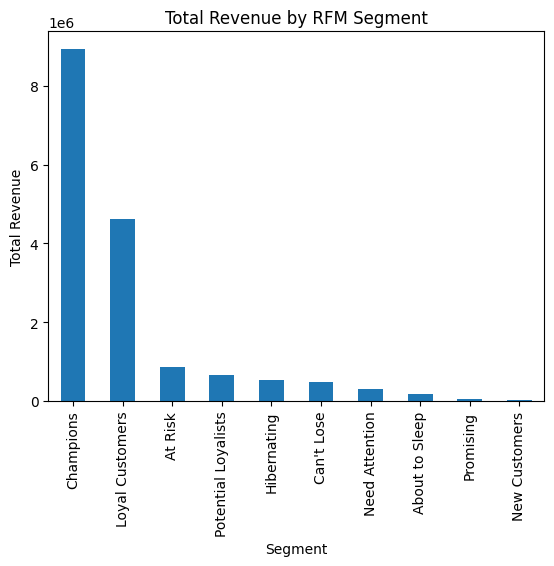

In [0]:
# Visualize segment revenue distribution
segment_revenue = rfm_seg.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

plt.figure()
segment_revenue.plot(kind="bar")
plt.title("Total Revenue by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=90)
plt.show()


In [0]:
# Display segment revenue series
rfm_seg.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

Segment
Champions              8936498.675
Loyal Customers        4620788.686
At Risk                 871659.340
Potential Loyalists     664396.090
Hibernating             521946.872
Can't Lose              487683.002
Need Attention          300661.891
About to Sleep          187894.022
Promising                38634.040
New Customers            18129.770
Name: Monetary, dtype: float64

In [0]:
display(rfm_seg)

customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
12346.0,325,17,-64.67999999999302,2,5,1,251,Can't Lose
12347.0,1,8,5633.32,5,4,5,545,Champions
12348.0,74,5,2019.4,3,3,4,334,Need Attention
12349.0,18,5,4404.54,4,3,5,435,Potential Loyalists
12350.0,309,1,334.4,2,1,2,212,Hibernating
12351.0,374,1,300.93,2,1,2,212,Hibernating
12352.0,35,13,1889.21,4,5,4,454,Loyal Customers
12353.0,203,2,406.76,2,2,2,222,Hibernating
12354.0,231,1,1079.4,2,1,3,213,Hibernating
12355.0,213,2,947.61,2,2,3,223,Hibernating


In [0]:
# Final RFM segment table
rf_segment_table = (
    rfm_seg
    .groupby(["R_score", "F_score", "Segment"])
    .size()
    .reset_index(name="CustomerCount")
)

rf_segment_table.head()


,R_score,F_score,Segment,CustomerCount
0,1,1,Hibernating,527
1,1,2,Hibernating,366
2,1,3,At Risk,173
3,1,4,At Risk,95
4,1,5,Can't Lose,15


In [0]:
# Final RFM segment table
rf_segment_table = (
    rfm_seg
    .groupby(["R_score", "F_score", "Segment"])
    .size()
    .reset_index(name="CustomerCount")
)


In [0]:
# Visualize segment distribution using Plotly
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

# Segment distribution table
seg_dist = (rfm_seg["Segment"].value_counts()
            .rename_axis("Segment")
            .reset_index(name="Customers"))
seg_dist["Pct"] = seg_dist["Customers"] / seg_dist["Customers"].sum() * 100

fig = px.bar(seg_dist, x="Segment", y="Pct", text=seg_dist["Pct"].round(1),
             title="Customer Distribution by Segment (%)")
fig.update_traces(textposition="outside")
fig.show()


In [0]:
# Interactive segment customer viewer
segment_dd = widgets.Dropdown(
    options=sorted(rfm_seg["Segment"].dropna().unique()),
    description="Segment:",
    layout=widgets.Layout(width="400px")
)

topn = widgets.IntSlider(
    value=20, min=5, max=200, step=5,
    description="Show top:",
    layout=widgets.Layout(width="400px")
)

out = widgets.Output()

def show_customers(change=None):
    with out:
        out.clear_output()
        seg = segment_dd.value

        # Customers in the segment (customize columns as you like)
        cols = ["customer_id", "Recency", "Frequency", "Monetary", "R_score", "F_score", "Segment"]
        cols = [c for c in cols if c in rfm_seg.columns]

        df_view = (rfm_seg[rfm_seg["Segment"] == seg]
                   .sort_values(["Monetary", "Frequency"], ascending=False)
                   .head(topn.value))

        display(df_view[cols])

segment_dd.observe(show_customers, names="value")
topn.observe(show_customers, names="value")

display(widgets.VBox([segment_dd, topn, out]))
show_customers()


## Remark
Based on RFM segmentation, the following customer groups were analyzed to understand their behavior and business impact.

---

## Segment Overview

### **Champions**
- **Number of customers:** 843  
- **Average last purchase:** ~7 days ago  
- **Average number of purchases:** ~24  
- **Average spend per customer:** ~£10,601  

**Business Insight:**  
Champions are the most valuable and most active customers. They purchase very frequently, spend the most, and have made recent purchases.

**Recommended Action:**  
These customers should be **retained at all costs**. Loyalty programs, exclusive offers, early access to products, and premium customer experience initiatives should be prioritized for this group.

---

### **Can’t Lose**
- **Number of customers:** 86  
- **Average last purchase:** ~319 days ago  
- **Average number of purchases:** ~18  
- **Average spend per customer:** ~£5,671  

**Business Insight:**  
Can’t Lose customers were high-value and frequent buyers in the past but have not purchased recently. Although the group is small, their historical value is significant.

**Recommended Action:**  
This segment requires **urgent, targeted win-back campaigns**. Personalized offers, reminders based on past purchases, and incentives such as discounts or gifts should be used to re-engage them.

---

### **Loyal Customers**
- **Number of customers:** 1162  
- **Average last purchase:** ~66 days ago  
- **Average number of purchases:** ~12  
- **Average spend per customer:** ~£3,977  

**Business Insight:**  
Loyal Customers form a strong and stable revenue base. They purchase regularly and contribute consistently, though not as frequently or recently as Champions.

**Recommended Action:**  
Maintain engagement through **regular communication**, cross-selling, and loyalty rewards to prevent them from slipping into At Risk segments.

---

### **At Risk**
- **Number of customers:** 754  
- **Average last purchase:** ~375 days ago  
- **Average number of purchases:** ~5  
- **Average spend per customer:** ~£1,156  

**Business Insight:**  
These customers used to engage but have not purchased for a long time. Their activity and spending have dropped significantly.

**Recommended Action:**  
Re-engagement campaigns should be applied selectively. Personalized reminders and time-limited discounts can help recover some of these customers before they become fully inactive.

---

### **Hibernating**
- **Number of customers:** 1535  
- **Average last purchase:** ~465 days ago  
- **Average number of purchases:** ~1  
- **Average spend per customer:** ~£340  

**Business Insight:**  
Hibernating customers represent the largest segment but have very low engagement and value. Most customers in this group purchased only once and have been inactive for a long time.

**Recommended Action:**  
Use **low-cost, broad campaigns** such as seasonal discounts. Heavy marketing spend on this group is unlikely to generate strong returns.

---

## Other Supporting Segments

- **Potential Loyalists (737 customers):** Recently active but low frequency — strong candidates for conversion into Loyal Customers.  
- **Need Attention (274 customers):** Moderate activity and spend — should be monitored closely.  
- **About to Sleep (383 customers):** Engagement is dropping — early intervention may prevent churn.  
- **New Customers (49 customers):** Recently acquired — focus on onboarding and second purchase.  
- **Promising (119 customers):** Low frequency but recent activity — nurture with follow-ups.

---

## Overall Conclusion
- **Revenue is driven by a relatively small group of highly engaged customers.**
- **Retention of Champions and Loyal Customers** is more valuable than mass acquisition.
- **High-value inactive customers (Can’t Lose)** present the biggest opportunity for revenue recovery.
- **Inactive, low-value customers (Hibernating)** should be approached cautiously with minimal cost.

---

### Executive Takeaway
> *Most customers are inactive, but most revenue comes from a small group of highly engaged customers, making targeted retention far more effective than broad campaigns.*
